
sarimaモデルとprophetモデルに関してのモデル比較を行う，扱うデータに対しては，https://www.kaggle.com/datasets/robikscube/hourly-energy-consumptionのデータセットにある，PJM East リージョン（地域）: 2002年～2018年 (PJME)
推定電力消費量（単位：メガワット [MW]）の予測である．

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
import holidays
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
from prophet import Prophet

In [65]:
file_path = 'PJME_hourly.csv'
df = pd.read_csv(file_path)

基本的な情報の確認

In [66]:
df.head()
df.info()
df['Datetime'] = pd.to_datetime(df['Datetime'])
df=df.sort_values(by='Datetime')
df=df.reset_index(drop=True)
dup_count = df['Datetime'].duplicated().sum()
dup_count
df= df.drop_duplicates(subset='Datetime')

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [67]:
df.head(24*365)

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0
...,...,...
8755,2002-12-31 22:00:00,29887.0
8756,2002-12-31 23:00:00,28483.0
8757,2003-01-01 00:00:00,27008.0
8758,2003-01-01 01:00:00,25591.0


欠損値の確認を行う,データ量の多さから(学習の時間を考えて)，2002から2005年を学習データとする，
その際にいくつか欠損しているので，線形で埋めることにする

In [68]:
ideal_range = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='h')
df_indexed = df.set_index('Datetime').reindex(ideal_range)
missing_dates = df_indexed[df_indexed['PJME_MW'].isnull()].index

print(f"合計欠損数: {len(missing_dates)}")
print("--- 欠損している日時の例（最初の10件） ---")
print(missing_dates[:10])



合計欠損数: 30
--- 欠損している日時の例（最初の10件） ---
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[us]', freq=None)


休日効果や，月効果をいれる

In [69]:
data = df_indexed.iloc[:24*365*4, :].interpolate(method='linear')
data = data.resample('D').mean().rename(columns={'PJME_MW': 'y'})
us_holidays = holidays.US()
data['month'] = data.index.month
data['is_holiday'] = data.index.map(lambda x: x in us_holidays).astype(int)
data= pd.get_dummies(data, columns=['month'], drop_first=True,dtype=int)


2002~2004までを訓練データ、その後の2006年をテストデータとして、予測を行う

In [70]:
data=data.reset_index().rename(columns={'index':'ds'})
train=data.iloc[:365*3+1,]
test=data.iloc[365*3+1:365*4+1,:]

In [71]:
train

,ds,y,is_holiday,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2002-01-01,31080.739130,1,0,0,0,0,0,0,0,0,0,0,0
1,2002-01-02,34261.541667,0,0,0,0,0,0,0,0,0,0,0,0
2,2002-01-03,34511.875000,0,0,0,0,0,0,0,0,0,0,0,0
3,2002-01-04,33715.458333,0,0,0,0,0,0,0,0,0,0,0,0
4,2002-01-05,30405.125000,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2004-12-27,36700.625000,0,0,0,0,0,0,0,0,0,0,0,1
1092,2004-12-28,37640.291667,0,0,0,0,0,0,0,0,0,0,0,1
1093,2004-12-29,34156.708333,0,0,0,0,0,0,0,0,0,0,0,1
1094,2004-12-30,32284.291667,0,0,0,0,0,0,0,0,0,0,0,1


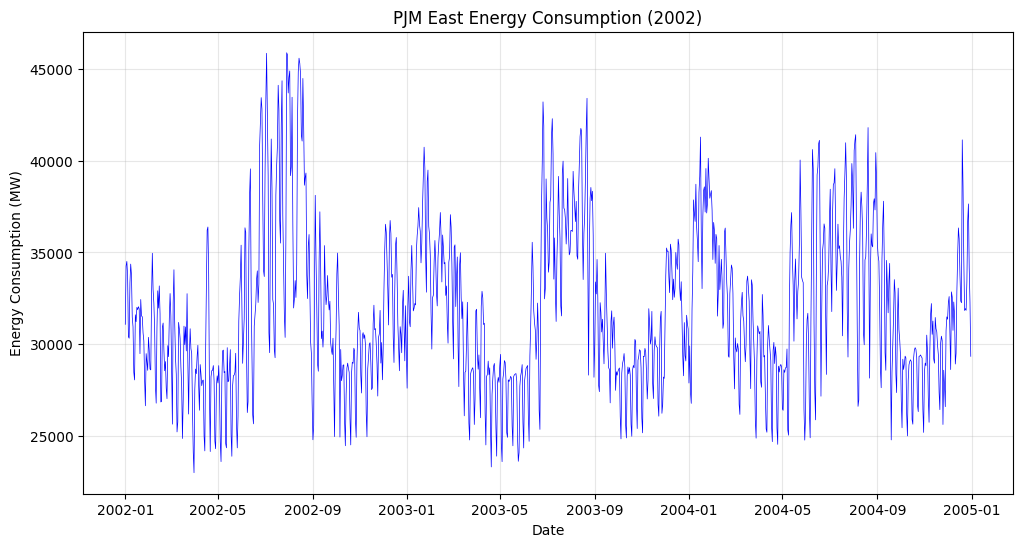

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.ds, train['y'], color='blue', linewidth=0.5)
ax.set_title('PJM East Energy Consumption (2002)')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Consumption (MW)')
ax.grid(True, alpha=0.3)

plt.show()

STLで分解してみる，

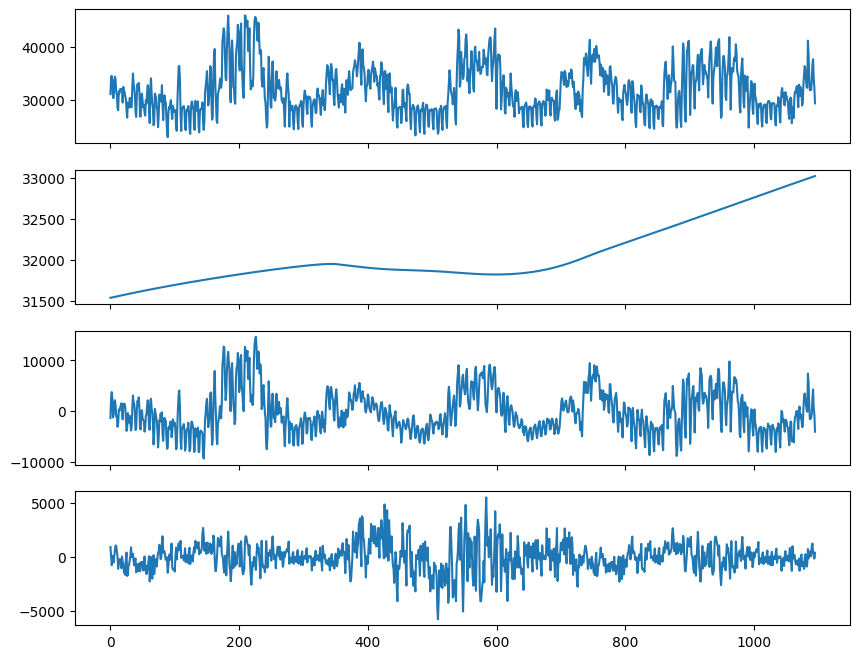

In [73]:
dec=STL(train["y"],period=365).fit()
fig,(ax1,ax2,ax3,ax4)=plt.subplots(nrows=4,ncols=1,sharex=True,figsize=(10,8))
ax1.plot(dec.observed)
ax2.plot(dec.trend)
ax3.plot(dec.seasonal)
ax4.plot(dec.resid)

ADF検定で，どのくらいラグを取るべきか考える，結果としては，ラグを取る必要はないが，季節に関しては，D=0,1を検討しようと思う．また，四季によって明らかな季節性がありそうなので，ここは外部変数で対応する．理由としては，s=365でとると大変なパラメータ数になるので，解析ができないと判断したためである．

In [74]:
a=adfuller(train.y)
a

(np.float64(-3.262587660117108),
 np.float64(0.01663591045673324),
 22,
 1073,
 {'1%': np.float64(-3.436459052172655),
  '5%': np.float64(-2.864237372528562),
  '10%': np.float64(-2.568206176974609)},
 np.float64(19150.06568957876))

モデル選定は，aicを基準に推定を行う．

In [75]:
def opt(endog : Union[pd.Series,list],exog,oreder_list,d,s):
    results=[]

    for i in tqdm_notebook(oreder_list):
        try:
            model=SARIMAX(endog,exog=exog,order=(i[0],d,i[1]),seasonal_order=(i[2],i[3],i[4],s),simple_differencing=False).fit(disp=False)
        except:
            continue
        aic=model.aic
        results.append([i,aic])

    result_book=pd.DataFrame(results,columns=["para","aic"])
    result_book=result_book.sort_values(by="aic",ascending=True).reset_index(drop=True)
    
    return result_book


In [76]:
p_range = range(0, 3)      # [0, 1, 2]
q_range = range(0, 3)      # [0, 1, 2]
P_range = range(0, 2)      # [0, 1]
D_range = [0, 1]           # 季節階差 (0 または 1)
Q_range = range(0, 2)      # [0, 1]
order_list = list(product(p_range, q_range, P_range, D_range, Q_range))

In [77]:
y_train = train['y']
X_train = train.drop(columns=['ds', 'y'])
res = opt(y_train, X_train, order_list, d=0, s=7)

/tmp/ipykernel_7398/3548560100.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(oreder_list):


  0%|          | 0/72 [00:00<?, ?it/s]

/home/popo/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: Co

In [78]:
res 

,para,aic
0,"(2, 2, 0, 1, 1)",19398.784567
1,"(2, 2, 1, 1, 1)",19410.042250
2,"(1, 2, 0, 1, 1)",19419.008460
3,"(1, 2, 1, 1, 1)",19419.148918
4,"(2, 1, 1, 1, 1)",19423.433195
...,...,...
67,"(0, 0, 1, 0, 0)",22493.369253
68,"(0, 0, 1, 0, 1)",22496.152114
69,"(0, 0, 0, 0, 1)",22886.056400
70,"(0, 0, 0, 1, 0)",27390.840757


(2, 2, 0, 1, 1)これを，ベストモデルとする

In [79]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 0, 2),
    seasonal_order=(0, 1, 1, 7),
    simple_differencing=False
)

results = model.fit(disp=True)


/home/popo/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/popo/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


リュング・ボックス検定に関しては合格.　jbに関しては，だめかなと．ただ，尖度から，裾部分が重い，つまり端に関してはよく外すことになっている
したがって，自己相関はないが，端に関しては大きく外していることが分かる．また，係数の有意性に関しては，一月基準なので，消すことはないし，そのまま使う

In [80]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 1096
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 7)   Log Likelihood               -9681.392
Date:                             Mon, 11 May 2026   AIC                          19398.785
Time:                                     19:49:24   BIC                          19488.659
Sample:                                          0   HQIC                         19432.801
                                            - 1096                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_holiday -2148.0538    202.556    -10.605      0.000   -2545.056   -1751.051
month_2    -1491.6520   1089.778     -1.369      0.171   -3627.578     644.274
month_3    -2767.2154    975.910     -2.836      0.005   -4679.965    -854.466
month_4    -1921.8177    934.197     -2.057      0.040   -3752.809     -90.826
month_5    -1849.8643   1117.925     -1.655      0.098   -4040.956     341.228
month_6    -1733.5968    801.138     -2.164      0.030   -3303.799    -163.395
month_7    -1062.8323    678.286     -1.567      0.117   -2392.248     266.583
month_8     -233.4316    711.485     -0.328      0.743   -1627.916    1161.053
month_9    -3646.7878    803.994     -4.536      0.000   -5222.587   -2070.988
month_10   -4375.0393   1062.236     -4.119      0.000   -6456.984   -2293.095
month_11   -4275.0706    760.853     -5.619      0.000   -5766.314   -2783.827
month_12    -686.8519    718.513     -0.956      0.339   -2095.112     721.408
ar.L1          1.6244      0.028     57.740      0.000       1.569       1.680
ar.L2         -0.6244      0.028    -22.571      0.000      -0.679      -0.570
ma.L1         -0.5128      0.035    -14.698      0.000      -0.581      -0.444
ma.L2         -0.4099      0.025    -16.234      0.000      -0.459      -0.360
ma.S.L7       -0.9999      0.049    -20.578      0.000      -1.095      -0.905
sigma2      3.724e+06      0.072   5.14e+07      0.000    3.72e+06    3.72e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):               285.54
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               0.61   Skew:                            -0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.13e+23. Standard errors may be unstable.
"""

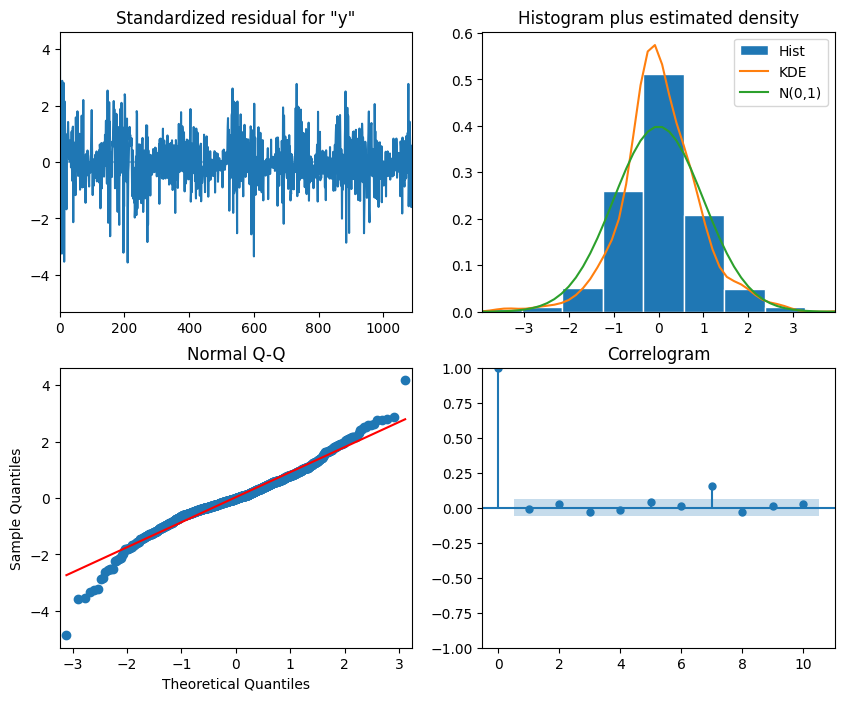

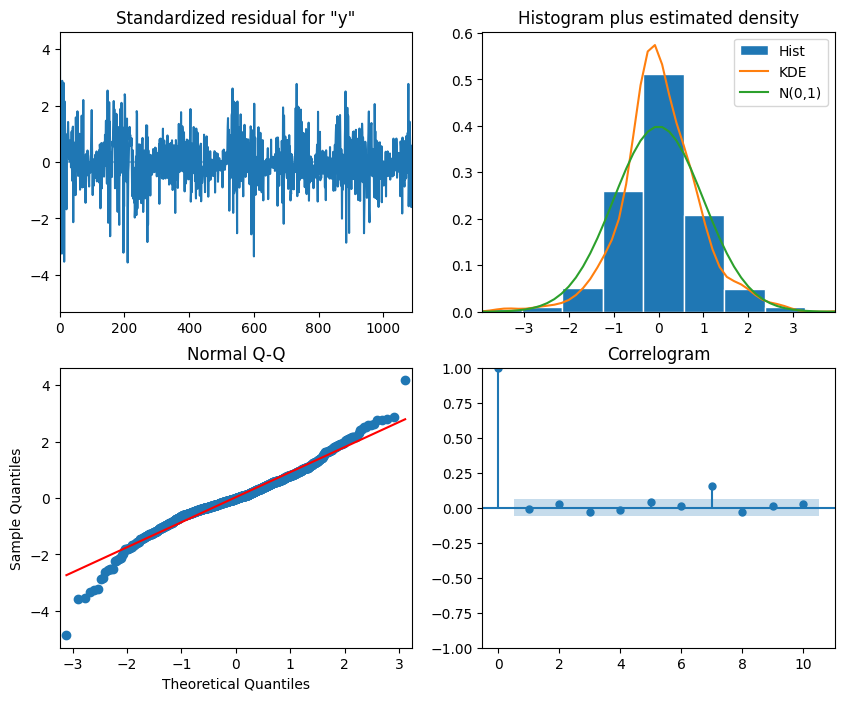

In [81]:
results.plot_diagnostics(figsize=(10,8))

testデータに対して予測をしてみる

In [82]:
y_test = test['y']
X_test = test.drop(columns=['ds', 'y'])

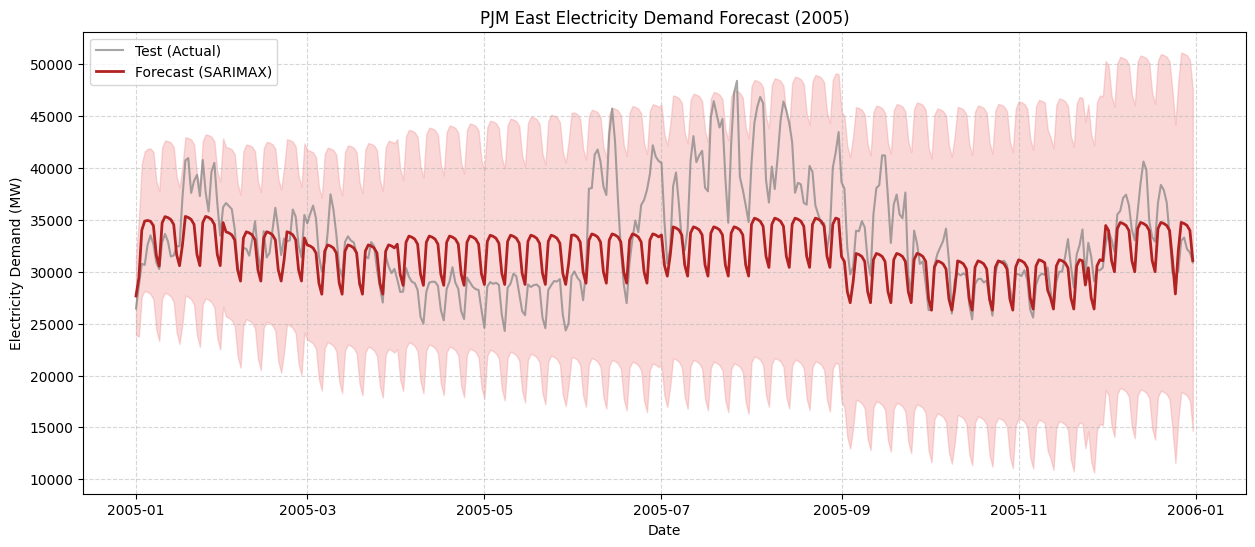

In [83]:
forecast = results.get_forecast(steps=len(test), exog=X_test)
y_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(15, 6))

plt.plot(test['ds'], y_test, label='Test (Actual)', color='gray', alpha=0.7)
plt.plot(test['ds'], y_pred, label='Forecast (SARIMAX)', color='firebrick', linewidth=2)

plt.fill_between(test['ds'], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightcoral', alpha=0.3)

plt.title('PJM East Electricity Demand Forecast (2005)')
plt.xlabel('Date')
plt.ylabel('Electricity Demand (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

そもそも，sarimaはローリング予測が向いているので...という感じですが，大きい変動に関しては予測が点でだめ，これはprophetでも同じなのかなという感じですが，次はprophetモデルに関してやっていきます．

In [84]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {rmse:.2f} ")
print(f"MAE : {mae:.2f} ")

RMSE: 4524.23 
MAE : 3495.21 


簡単に説明する，cross valitationでパラメータの推定を行う，

In [85]:
from prophet.diagnostics import cross_validation, performance_metrics

param_grid = {  
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
rmses = []
for params in all_params:
    m = Prophet(**params)
    for col in X_train:
        m.add_regressor(col)
        
    m.fit(train)
    df_cv = cross_validation(m, initial='540 days', period='90 days', horizon='180 days', parallel='processes')
    
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[tuning_results['rmse'].idxmin()]

print(f"--- 最良のパラメータ ---")
print(best_params)

19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
19:49:25 - cmdstanpy - INFO - Chain [1] done processing
19:49:25 - cmdstanpy - INFO - Ch

--- 最良のパラメータ ---
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01}


19:49:21 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
final_model = Prophet(**best_params)
for col in X_train:
        final_model.add_regressor(col)
final_model.fit(train)

19:49:21 - cmdstanpy - INFO - Chain [1] start processing
19:49:21 - cmdstanpy - INFO - Chain [1] done processing


In [87]:
future=test.drop(columns=["y"])
forecast = final_model.predict(future)
y_pred_prophet = forecast['yhat'].values
y_true = test['y'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred_prophet))
mae = mean_absolute_error(y_true, y_pred_prophet)


print(f"Prophet + 説明変数 予測精度")
print(f"RMSE: {rmse:.2f} ")
print(f"MAE: {mae:.2f}")

Prophet + 説明変数 予測精度
RMSE: 3154.15 
MAE: 2329.74


sarimaモデルよりも、精度もよいし、傾向もとらえることができていることが分かる。ただし、いずれにしても、誤差は大きいし、ピーク点をとらえることは容易ではなさそうである

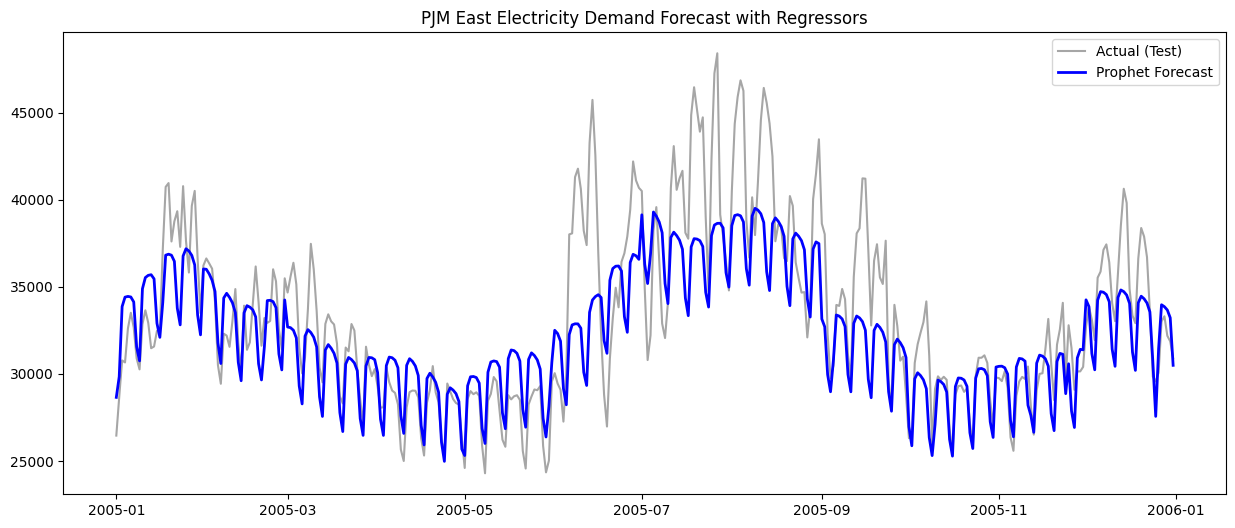

In [88]:
plt.figure(figsize=(15, 6))
plt.plot(test['ds'], y_true, label='Actual (Test)', color='gray', alpha=0.7)
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='blue', linewidth=2)
plt.title('PJM East Electricity Demand Forecast with Regressors')
plt.legend()
plt.show()